In [46]:
# 1. Importing Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("C:/Users/user/Downloads/movies.csv")
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7668, 15)


In [8]:
df.columns

Index(['name', 'rating', 'genre', 'year', 'released', 'score', 'votes',
       'director', 'writer', 'star', 'country', 'budget', 'gross', 'company',
       'runtime'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [10]:
df.describe()

,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


In [13]:
df.sample(5)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
505,Nausicaä of the Valley of the Wind,NaN,Animation,1984,"November 25, 1987 (United States)",8.1,157000.0,Hayao Miyazaki,Hayao Miyazaki,Sumi Shimamoto,Japan,1000000.0,8736506.0,Nibariki,117.0
4654,Wedding Crashers,R,Comedy,2005,"July 15, 2005 (United States)",6.9,339000.0,David Dobkin,Steve Faber,Owen Wilson,United States,40000000.0,288467645.0,New Line Cinema,119.0
7234,The Last Movie Star,R,Drama,2017,"March 30, 2018 (United States)",7.0,3700.0,Adam Rifkin,Adam Rifkin,Burt Reynolds,United States,NaN,14410.0,Broken Twig Productions Inc.,94.0
3339,Apt Pupil,R,Crime,1998,"October 23, 1998 (United States)",6.7,37000.0,Bryan Singer,Stephen King,Ian McKellen,United States,14000000.0,8863193.0,Phoenix Pictures,111.0
5281,The Other Boleyn Girl,PG-13,Biography,2008,"February 29, 2008 (United States)",6.7,107000.0,Justin Chadwick,Peter Morgan,Natalie Portman,United Kingdom,35000000.0,78201830.0,Columbia Pictures,115.0


In [14]:
print("Total duplicated rows:", df.duplicated().sum())

Total duplicated rows: 0


In [15]:
df = df.drop_duplicates()

In [16]:
print("Total duplicated rows after dropping:", df.duplicated().sum())

Total duplicated rows after dropping: 0


In [17]:
df.isnull().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

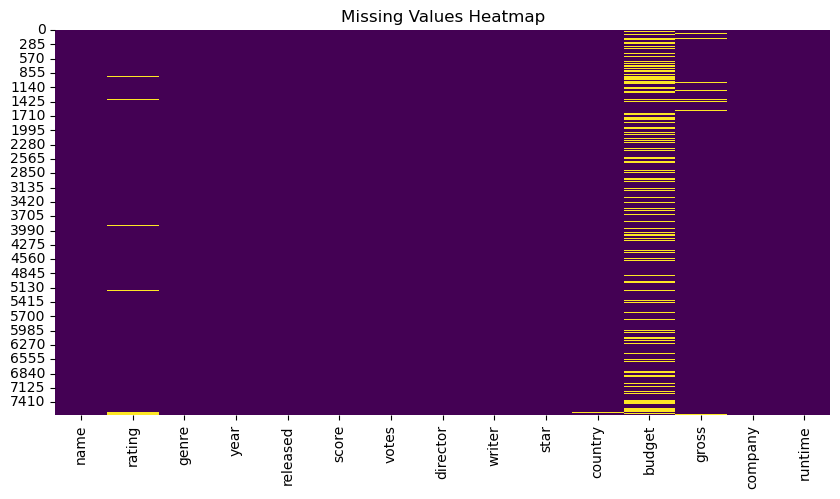

In [18]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns
print("Numeric Columns:", numeric_cols.tolist())
print("Categorical Columns:", categorical_cols.tolist())

Numeric Columns: ['year', 'score', 'votes', 'budget', 'gross', 'runtime']
Categorical Columns: ['name', 'rating', 'genre', 'released', 'director', 'writer', 'star', 'country', 'company']


In [20]:
# Impute numeric columns with median
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Impute categorical columns with mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [21]:
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64


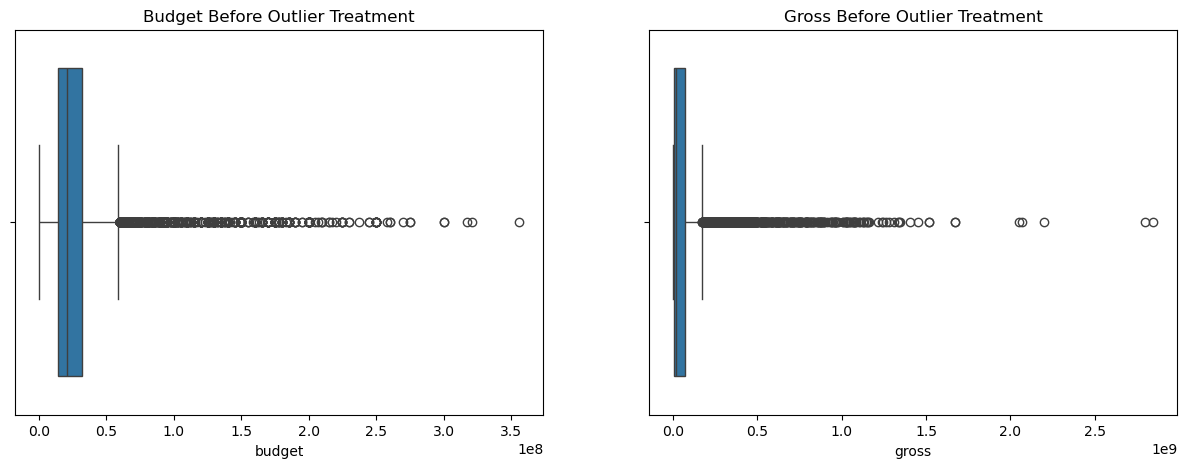

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['budget'], ax=axes[0]).set_title('Budget Before Outlier Treatment')
sns.boxplot(x=df['gross'], ax=axes[1]).set_title('Gross Before Outlier Treatment')
plt.show()

In [24]:
def cap_outliers(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping outliers
    dataframe[column] = np.where(dataframe[column] < lower_bound, lower_bound, dataframe[column])
    dataframe[column] = np.where(dataframe[column] > upper_bound, upper_bound, dataframe[column])
    return dataframe

# Apply IQR Capping to budget and gross
df = cap_outliers(df, 'budget')
df = cap_outliers(df, 'gross')

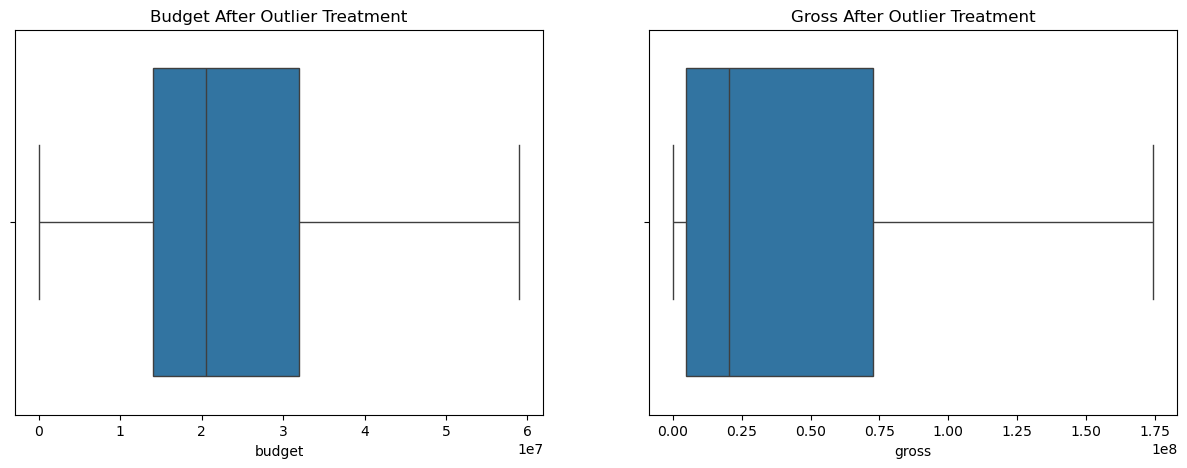

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['budget'], ax=axes[0]).set_title('Budget After Outlier Treatment')
sns.boxplot(x=df['gross'], ax=axes[1]).set_title('Gross After Outlier Treatment')
plt.show()

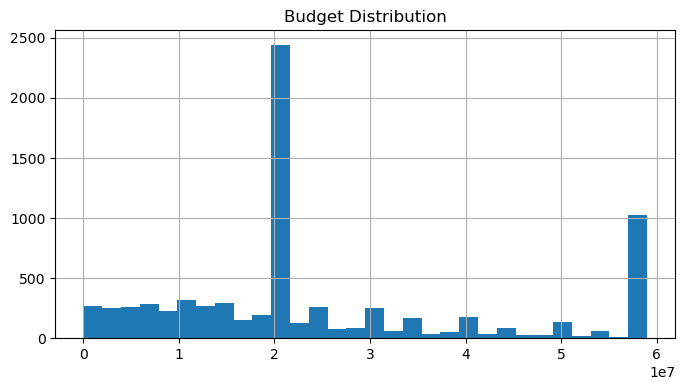

In [26]:
df['budget'].hist(bins=30, figsize=(8,4))
plt.title('Budget Distribution')
plt.show()

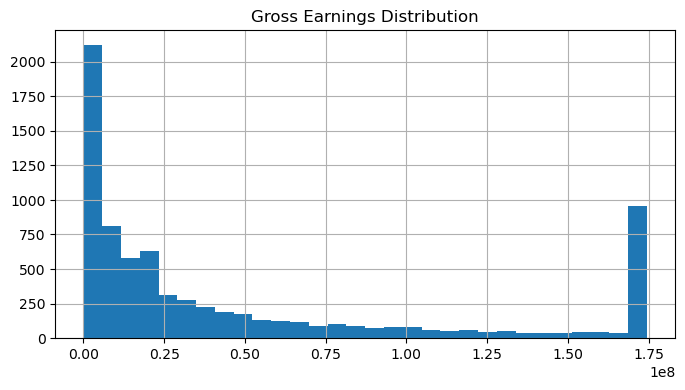

In [27]:
df['gross'].hist(bins=30, figsize=(8,4))
plt.title('Gross Earnings Distribution')
plt.show()

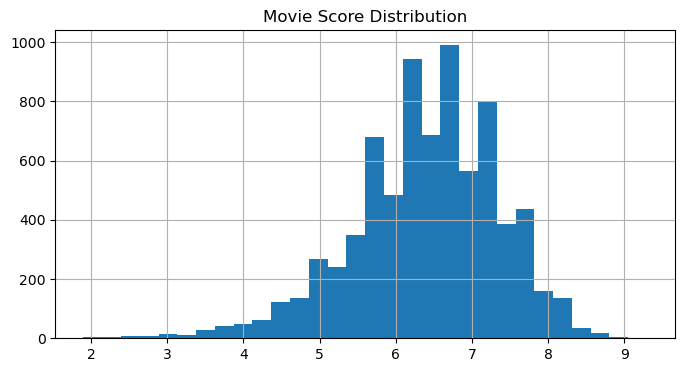

In [28]:
df['score'].hist(bins=30, figsize=(8,4))
plt.title('Movie Score Distribution')
plt.show()

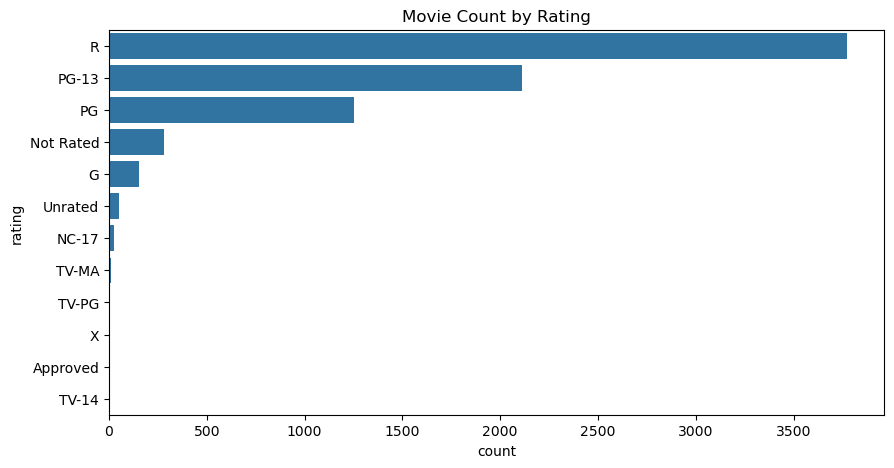

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(y=df['rating'], order=df['rating'].value_counts().index)
plt.title('Movie Count by Rating')
plt.show()

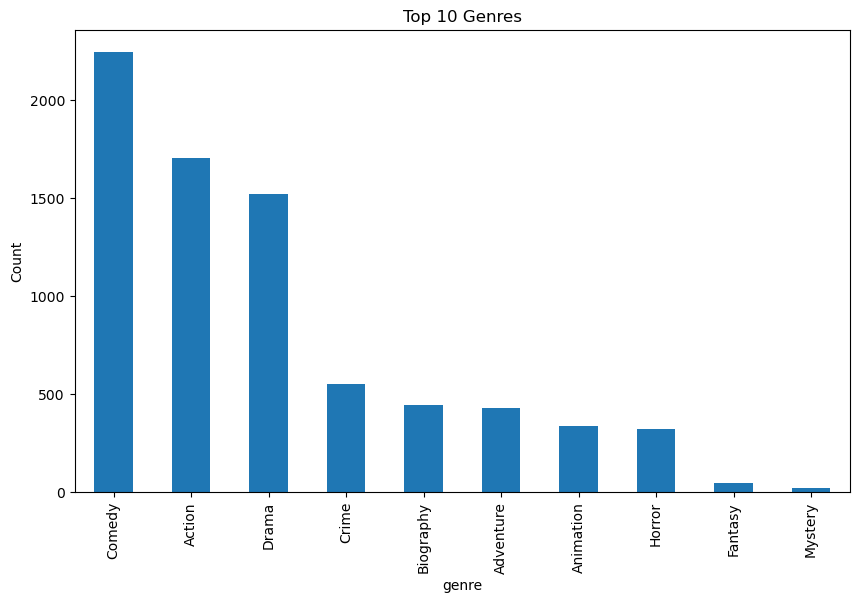

In [30]:
plt.figure(figsize=(10,6))
df['genre'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genres')
plt.ylabel('Count')
plt.show()

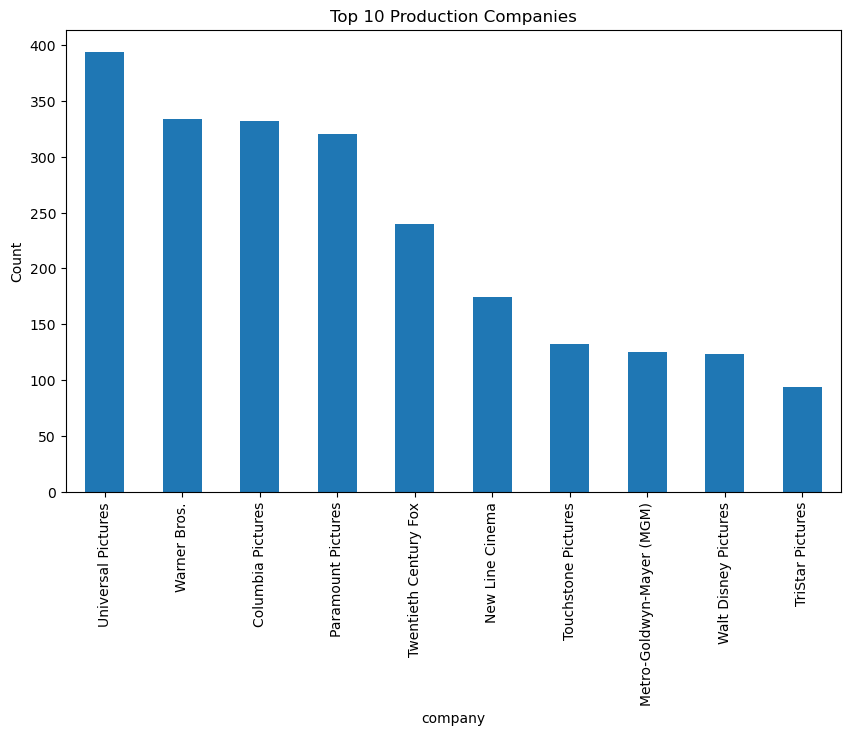

In [31]:
plt.figure(figsize=(10,6))
df['company'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Production Companies')
plt.ylabel('Count')
plt.show()

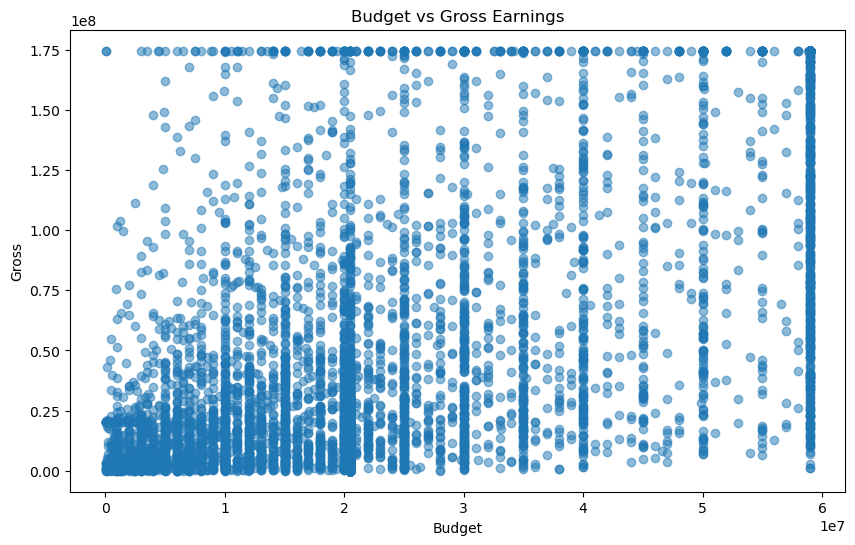

In [32]:
    plt.figure(figsize=(10,6))
    plt.scatter(df['budget'], df['gross'], alpha=0.5)
    plt.title('Budget vs Gross Earnings')
    plt.xlabel('Budget')
    plt.ylabel('Gross')
    plt.show()

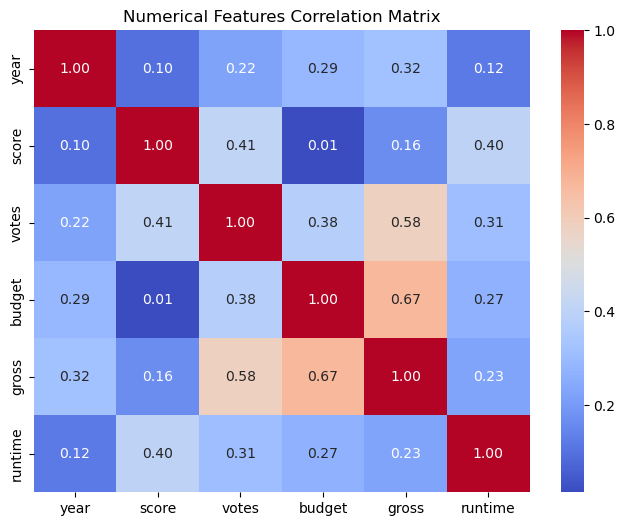

In [33]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Features Correlation Matrix')
plt.show()

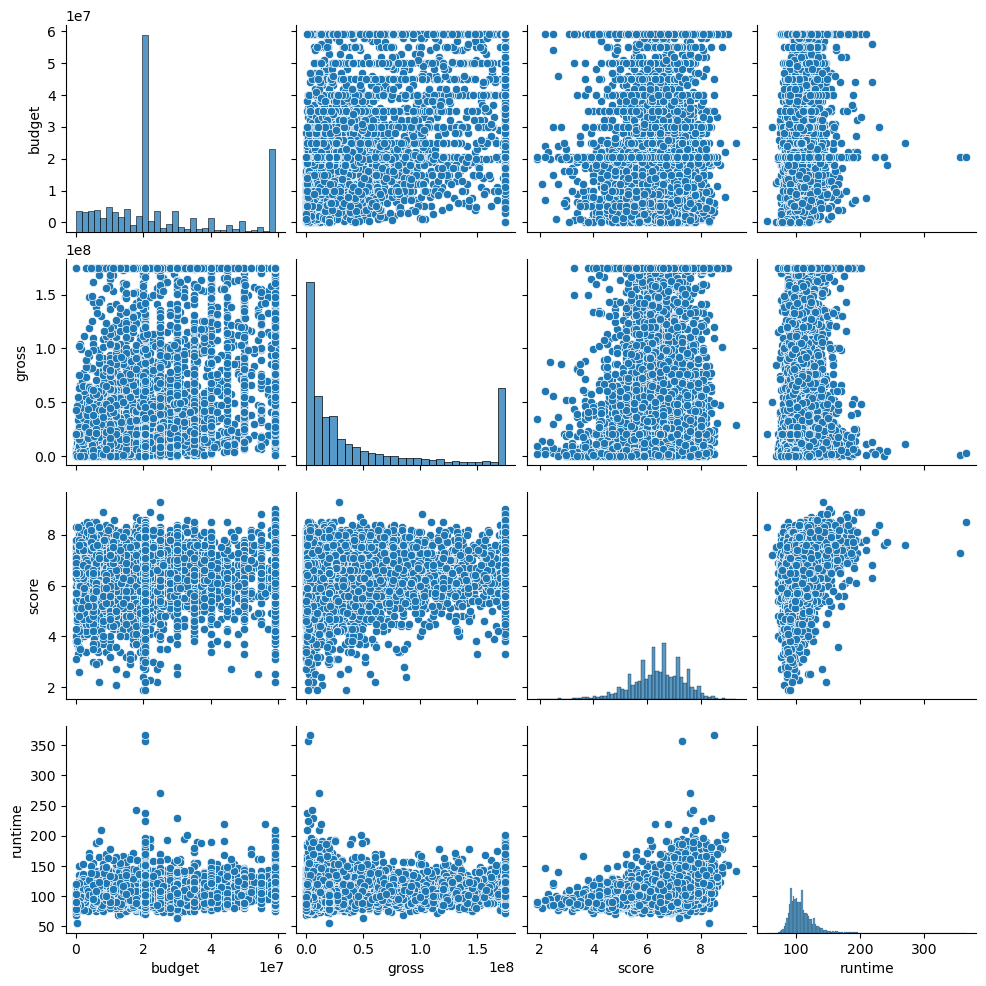

In [34]:
sns.pairplot(df[['budget','gross','score','runtime']])
plt.show()

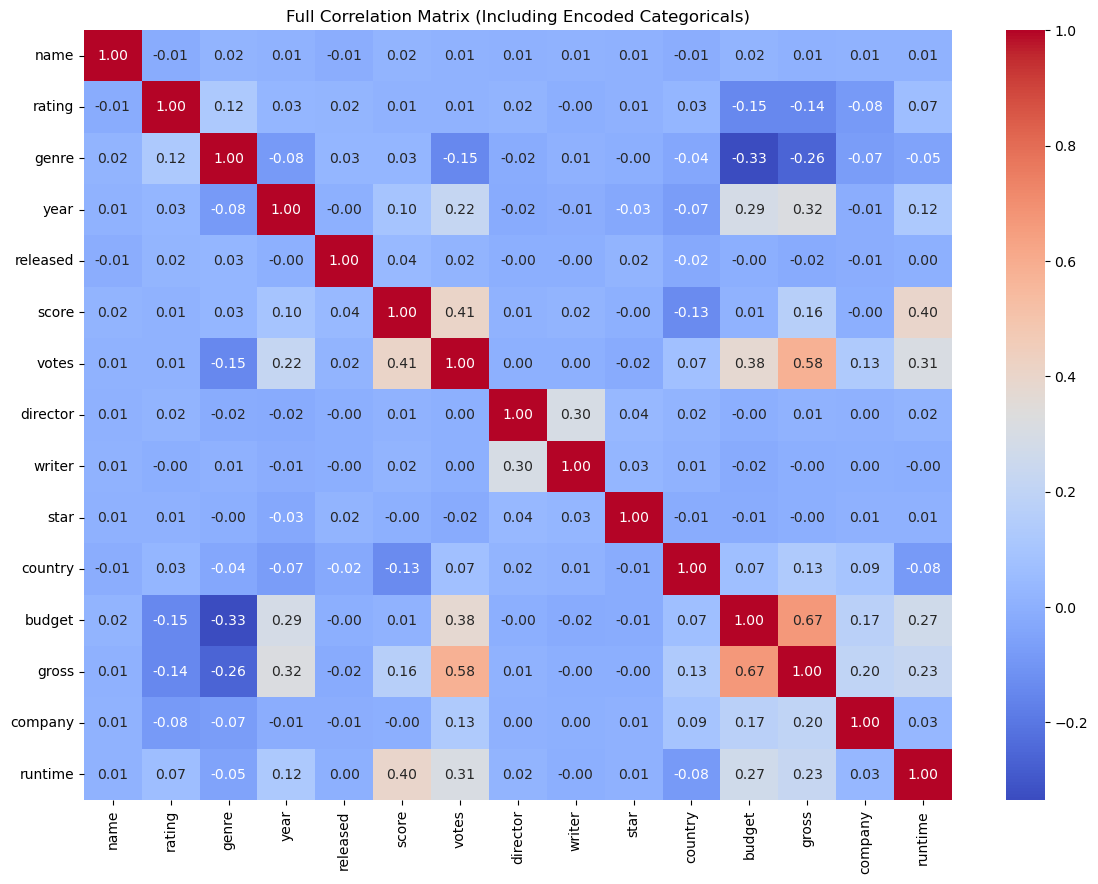

In [35]:
from sklearn.preprocessing import LabelEncoder
df_numerized = df.copy()
le = LabelEncoder()

for col in df_numerized.columns:
    if df_numerized[col].dtype == 'object':
        df_numerized[col] = le.fit_transform(df_numerized[col].astype(str))

plt.figure(figsize=(14,10))
sns.heatmap(df_numerized.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Full Correlation Matrix (Including Encoded Categoricals)')
plt.show()

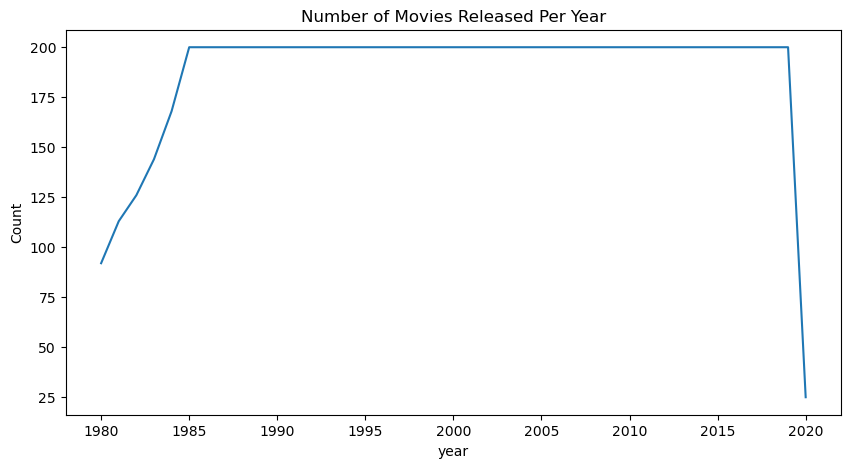

In [37]:
plt.figure(figsize=(10,5))
df.groupby('year').size().plot()
plt.title('Number of Movies Released Per Year')
plt.ylabel('Count')
plt.show()

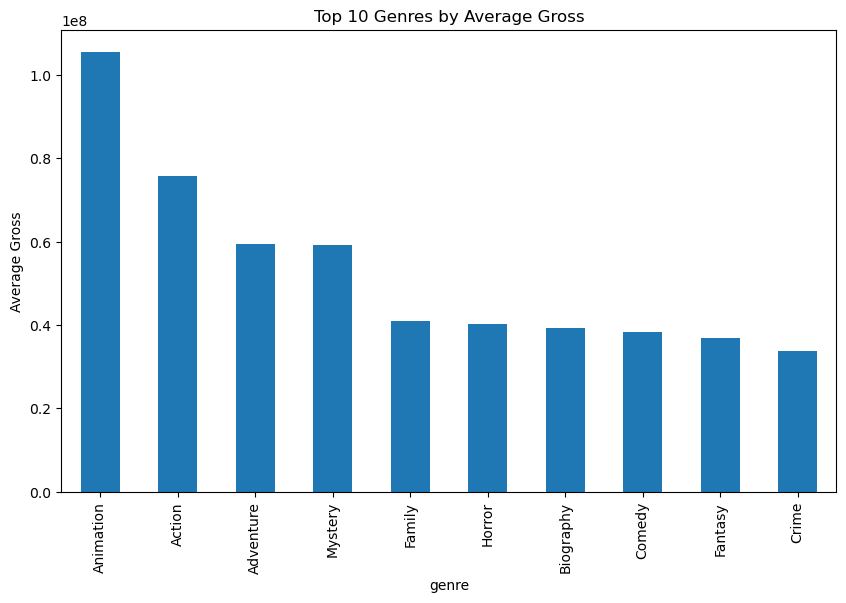

In [38]:
plt.figure(figsize=(10,6))
df.groupby('genre')['gross'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Genres by Average Gross')
plt.ylabel('Average Gross')
plt.show()

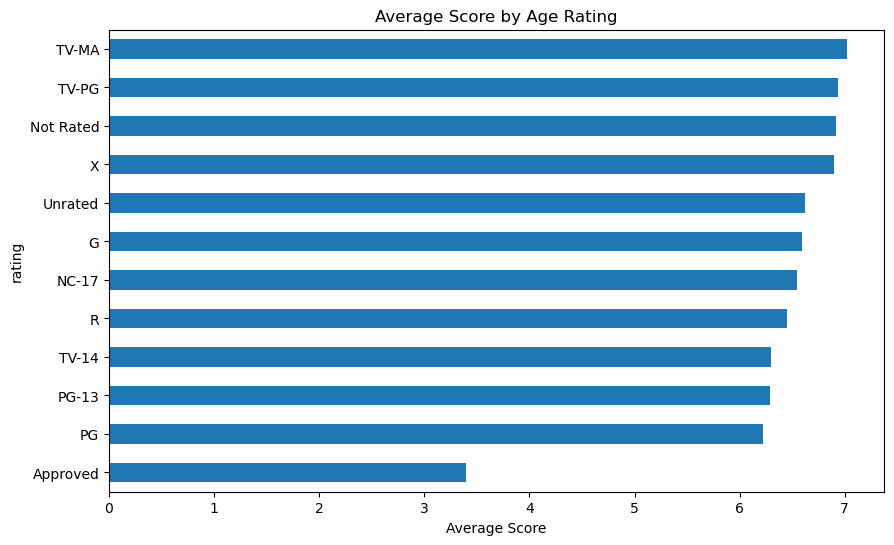

In [39]:
plt.figure(figsize=(10,6))
df.groupby('rating')['score'].mean().sort_values().plot(kind='barh')
plt.title('Average Score by Age Rating')
plt.xlabel('Average Score')
plt.show()

In [40]:
print("Top 10 Movies by Gross Earnings:")
top_movies = df.sort_values('gross', ascending=False).head(10)
top_movies[['name', 'gross', 'year', 'director']]

Top 10 Movies by Gross Earnings:


,name,gross,year,director
6079,John Carter,1.745288e+08,2012,Andrew Stanton
7060,The Boss Baby,1.745288e+08,2017,Tom McGrath
6863,Zootopia,1.745288e+08,2016,Byron Howard
6862,Passengers,1.745288e+08,2016,Morten Tyldum
6861,The Conjuring 2,1.745288e+08,2016,James Wan
1855,Beauty and the Beast,1.745288e+08,1991,Gary Trousdale
6860,La La Land,1.745288e+08,2016,Damien Chazelle
6859,Sing,1.745288e+08,2016,Garth Jennings
6858,Star Trek Beyond,1.745288e+08,2016,Justin Lin
2855,101 Dalmatians,1.745288e+08,1996,Stephen Herek


In [42]:
df.to_csv('movies_cleaned.csv', index=False)
print("Cleaned dataset saved as 'movies_cleaned.csv'.")
df.head()

Cleaned dataset saved as 'movies_cleaned.csv'.


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,4.699877e+07,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,5.885311e+07,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,1.745288e+08,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,8.345354e+07,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,3.984634e+07,Orion Pictures,98.0
